In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *
import os

import tensorflow as tf
from tensorflow.keras.models import load_model

2025-08-20 22:28:38.168648: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-20 22:28:38.194916: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755709118.225754  192330 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755709118.235145  192330 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755709118.258646  192330 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [ ]:
PATH = "Path of dataset"

In [2]:
def symmetry_aware_bce(y_true, y_pred):
    y_true = tf.convert_to_tensor(y_true, dtype=tf.float32)
    y_pred = tf.convert_to_tensor(y_pred, dtype=tf.float32)
    y_true_flipped = tf.reverse(y_true, axis=[1])
    bce_normal = tf.keras.backend.binary_crossentropy(y_true, y_pred)
    bce_flipped = tf.keras.backend.binary_crossentropy(y_true_flipped, y_pred)
    loss_normal = tf.reduce_mean(bce_normal, axis=[1, 2])
    loss_flipped = tf.reduce_mean(bce_flipped, axis=[1, 2])
    return tf.reduce_mean(tf.minimum(loss_normal, loss_flipped)).numpy()

def symmetry_aware_mse(true_shape, predicted_shape):
    mse_normal = np.mean((true_shape - predicted_shape) ** 2, axis=(1, 2))
    true_flipped = np.flip(true_shape, axis=1)  # Flip vertically
    mse_flipped = np.mean((true_flipped - predicted_shape) ** 2, axis=(1, 2))
    min_mse = np.minimum(mse_normal, mse_flipped)
    return np.mean(min_mse)

In [3]:
# # File paths
LCs_files = [
    "test_type0","test_typeIa", "test_typeIb", "test_typeIIa",
    "test_typeIIb", "test_typeIII", "test_typeIV", "test_typeV"
]
OMs_files = [
    "test_type0","test_typeIa", "test_typeIb", "test_typeIIa",
    "test_typeIIb", "test_typeIII", "test_typeIV", "test_typeV"
]
SNRs = [50, 75, 100, 150, 200, 500]
OM_file = PATH+"FinalData/OM/"
LCs_file = PATH+"FinalData/LC/"

In [4]:
# Load model
model1 = load_model(PATH+'Train/Model0.h5', compile=False)

2025-08-20 22:28:42.036464: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [5]:
bce_errors = []
mse_errors = []

# Loop over SNRs
for snr in SNRs:
    print(f"\n🔹 Evaluating SNR={snr}")

    LC_path = f"FinalData/LC10/{snr}/"
    OM_path = "FinalData/OM/"

    all_lcs = []
    all_oms = []

    for lc_file, om_file in zip(LCs_files, OMs_files):
        lcs = np.load(LC_path + lc_file + ".npy")
        oms = np.load(OM_path + om_file + ".npy")
        all_lcs.append(lcs)
        all_oms.append(oms)

    all_lcs = np.concatenate(all_lcs, axis=0)
    all_oms = np.concatenate(all_oms, axis=0)

    print(all_oms.shape, all_lcs.shape)
    preds = model1.predict(all_lcs, verbose=0)

    bce_err = symmetry_aware_bce(all_oms, preds)
    mse_err = symmetry_aware_mse(all_oms, preds)

    bce_errors.append(bce_err)
    mse_errors.append(mse_err)

    print(f"✅ SNR={snr} | Symmetry-aware BCE: {bce_err:.5f} | Symmetry-aware MSE: {mse_err:.5f}")





🔹 Evaluating SNR=50
(8890, 38, 38) (8890, 120)


✅ SNR=50 | Symmetry-aware BCE: 0.35123 | Symmetry-aware MSE: 0.11009

🔹 Evaluating SNR=75
(8890, 38, 38) (8890, 120)
✅ SNR=75 | Symmetry-aware BCE: 0.31411 | Symmetry-aware MSE: 0.09994

🔹 Evaluating SNR=100
(8890, 38, 38) (8890, 120)
✅ SNR=100 | Symmetry-aware BCE: 0.29702 | Symmetry-aware MSE: 0.09476

🔹 Evaluating SNR=150
(8890, 38, 38) (8890, 120)
✅ SNR=150 | Symmetry-aware BCE: 0.27815 | Symmetry-aware MSE: 0.08874

🔹 Evaluating SNR=200
(8890, 38, 38) (8890, 120)
✅ SNR=200 | Symmetry-aware BCE: 0.26681 | Symmetry-aware MSE: 0.08496

🔹 Evaluating SNR=500
(8890, 38, 38) (8890, 120)
✅ SNR=500 | Symmetry-aware BCE: 0.23591 | Symmetry-aware MSE: 0.07468


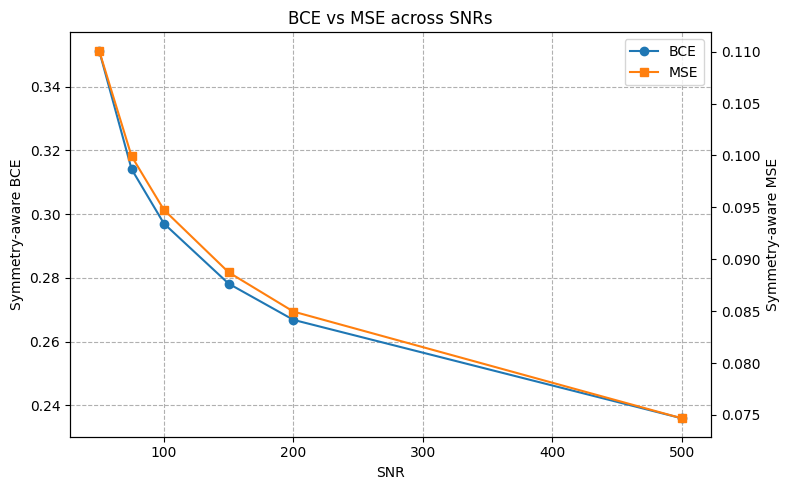

In [6]:
fig, ax1 = plt.subplots(figsize=(8,5))

# Left y-axis (BCE)
ax1.set_xlabel("SNR")
ax1.set_ylabel("Symmetry-aware BCE")
ax1.plot(SNRs, bce_errors, marker="o", color="tab:blue", label="BCE")
ax1.tick_params(axis="y")

# Right y-axis (MSE)
ax2 = ax1.twinx()
ax2.set_ylabel("Symmetry-aware MSE")
ax2.plot(SNRs, mse_errors, marker="s", color="tab:orange",label="MSE")
ax2.tick_params(axis="y")

# Title
plt.title("BCE vs MSE across SNRs")

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

# Grid aligned with x-axis
ax1.grid(True, which="both", axis="both", linestyle="--", alpha=1)

plt.tight_layout()
plt.show()
